# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA only if the numerical features show a correlation.


In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')

In [214]:
print(df.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

In [215]:
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [216]:
df_quantitive = df.select_dtypes(include=['number'])

In [217]:
# Calculate the sum of missing values per column
missing_values = df.isna().sum()

# Filter and display ONLY the columns where missing values are greater than 0
print(missing_values[missing_values > 0])

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [218]:
df_quantitive

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,0,40,0,0,0,0,0,8,2007,175000
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,349,0,0,0,0,0,0,2,2010,210000
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,0,60,0,0,0,0,2500,5,2010,266500
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,366,0,112,0,0,0,0,4,2010,142125


In [219]:
missing_values = df_quantitive.isna().sum()

print(missing_values[missing_values > 0])

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64


now dealing with this missing values

MasVnrArea       8  Remove it since it is small part of the data

GarageYrBlt     81  Make it 0 because it probably means no grage space that way it is not recorded

LotFrontage    259  Replace it with the median because it will be better then using the mean that will be affected by outliar

In [220]:
df_quantitive = df_quantitive[df_quantitive['MasVnrArea'].notna()]
df_quantitive['GarageYrBlt'] = df_quantitive['GarageYrBlt'].fillna(0)
df_quantitive['LotFrontage'] = df_quantitive['LotFrontage'].fillna(df_quantitive['LotFrontage'].median())
df_quantitive[['MasVnrArea','GarageYrBlt','LotFrontage']].isna().sum()




MasVnrArea     0
GarageYrBlt    0
LotFrontage    0
dtype: int64

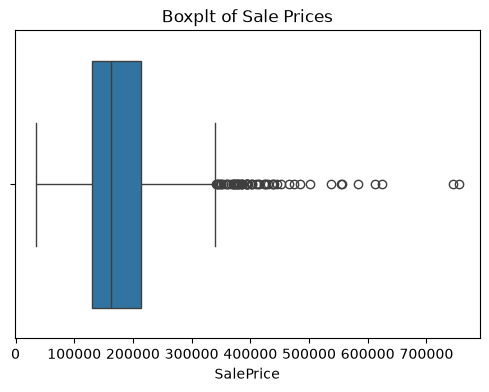

In [221]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_quantitive['SalePrice'])

plt.title('Boxplt of Sale Prices')
plt.show()

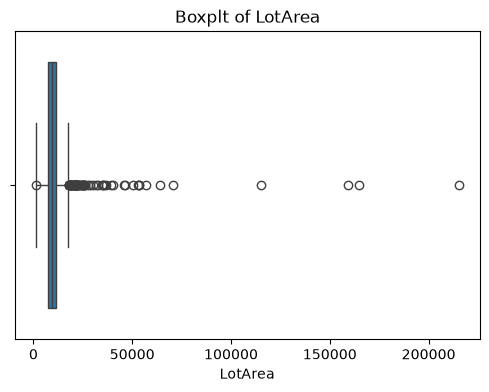

In [222]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_quantitive['LotArea'])

plt.title('Boxplt of LotArea')
plt.show()

In [223]:
Q1 = df_quantitive.quantile(0.25)
Q3 = df_quantitive.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df_quantitive[(df_quantitive < lower) | (df_quantitive > upper)]


# Create an empty dictionary to store arrays of varying lengths
outliers_per_feature = {}

# Loop through every single column in the DataFrame
for col in df_quantitive.columns:
    # 1. Find rows where this specific column exceeds its lower or upper bounds
    is_outlier = (df_quantitive[col] < lower[col]) | (df_quantitive[col] > upper[col])
    
    # 2. Extract those values, drop any NaNs, and convert them to a Python list
    clean_outliers = df_quantitive[col][is_outlier].dropna().tolist()
    
    # 3. Save the list to our dictionary only if the feature actually has outliers
    if len(clean_outliers) > 0:
        outliers_per_feature[col] = clean_outliers

# Print each feature and its isolated array of outliers
for feature, values in outliers_per_feature.items():
    print(f"{feature} Outliers (Total: {len(values)})")
    print(values)
    print("-" * 40)


MSSubClass Outliers (Total: 103)
[190, 190, 160, 180, 160, 190, 160, 190, 160, 190, 160, 160, 160, 160, 160, 160, 160, 160, 160, 190, 160, 190, 190, 190, 190, 160, 160, 160, 190, 160, 160, 180, 180, 190, 180, 160, 160, 160, 190, 190, 160, 160, 160, 180, 160, 190, 190, 180, 160, 160, 160, 160, 190, 190, 190, 160, 160, 160, 160, 160, 190, 160, 160, 160, 160, 160, 190, 160, 160, 190, 160, 160, 190, 160, 180, 190, 160, 160, 160, 160, 160, 190, 160, 160, 190, 190, 160, 160, 160, 160, 190, 160, 180, 160, 160, 160, 160, 160, 160, 190, 190, 180, 180]
----------------------------------------
LotFrontage Outliers (Total: 106)
[110.0, 108.0, 112.0, 115.0, 110.0, 24.0, 21.0, 121.0, 122.0, 24.0, 120.0, 134.0, 110.0, 141.0, 24.0, 24.0, 174.0, 21.0, 21.0, 174.0, 21.0, 21.0, 120.0, 30.0, 129.0, 140.0, 120.0, 118.0, 116.0, 150.0, 111.0, 21.0, 109.0, 130.0, 21.0, 24.0, 21.0, 137.0, 110.0, 21.0, 21.0, 24.0, 130.0, 24.0, 30.0, 21.0, 21.0, 21.0, 120.0, 110.0, 24.0, 24.0, 30.0, 110.0, 144.0, 114.0, 24.0, 30

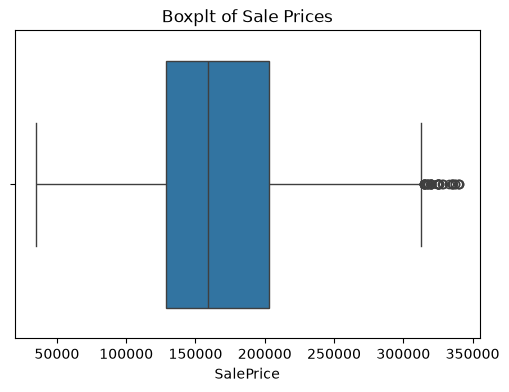

In [224]:
df_quantitive_no_outliers = df_quantitive[(df_quantitive >= lower) & (df_quantitive <= upper)]
plt.figure(figsize=(6,4))
sns.boxplot(x=df_quantitive_no_outliers['SalePrice'])

plt.title('Boxplt of Sale Prices')
plt.show()



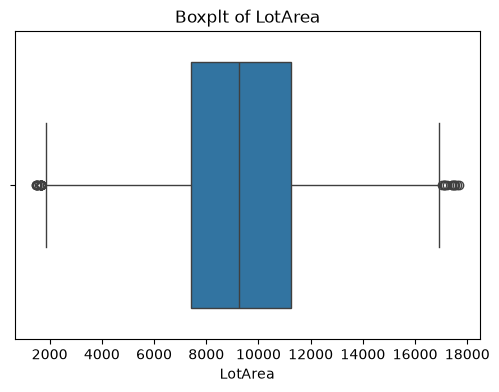

In [225]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_quantitive_no_outliers['LotArea'])

plt.title('Boxplt of LotArea')
plt.show()

In [226]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df_quantitive[['SalePrice', 'LotArea']].copy()

df_scaled[['SalePrice', 'LotArea']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,SalePrice,LotArea
0,0.241078,0.033420
1,0.203583,0.038795
2,0.261908,0.046507
3,0.145952,0.038561
4,0.298709,0.060576


In [227]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df_quantitive.copy()

# Scale and convert back to DataFrame
df_standardized = pd.DataFrame(
    scaler.fit_transform(df_standardized), 
    columns=df_standardized.columns, 
    index=df_standardized.index
)

df_standardized

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,-1.727915,0.072083,-0.220060,-0.206014,0.656877,-0.520512,1.056331,0.882742,0.510015,0.580026,...,-0.753221,0.221269,-0.359223,-0.116664,-0.271006,-0.068882,-0.087931,-1.600089,0.138937,0.351824
1,-1.725545,-0.872973,0.460848,-0.090854,-0.067334,2.175506,0.161798,-0.425058,-0.572835,1.177561,...,1.624112,-0.702611,-0.359223,-0.116664,-0.271006,-0.068882,-0.087931,-0.488448,-0.613809,0.011165
2,-1.723174,0.072083,-0.083879,0.074376,0.656877,-0.520512,0.990069,0.834305,0.322174,0.096725,...,-0.753221,-0.066497,-0.359223,-0.116664,-0.271006,-0.068882,-0.087931,0.993739,0.138937,0.541079
3,-1.720803,0.308347,-0.447030,-0.095861,0.656877,-0.520512,-1.859183,-0.715681,-0.572835,-0.496416,...,-0.753221,-0.172516,4.094767,-0.116664,-0.271006,-0.068882,-0.087931,-1.600089,-1.366555,-0.512440
4,-1.718432,0.072083,0.642424,0.375794,1.381088,-0.520512,0.956938,0.737431,1.360826,0.467988,...,0.778484,0.569618,-0.359223,-0.116664,-0.271006,-0.068882,-0.087931,2.105380,0.138937,0.875429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1.721646,0.072083,-0.356242,-0.259388,-0.067334,-0.520512,0.923807,0.737431,-0.572835,-0.970929,...,-0.753221,-0.096788,-0.359223,-0.116664,-0.271006,-0.068882,-0.087931,0.623192,-0.613809,-0.070845
1456,1.724016,-0.872973,0.687817,0.267143,-0.067334,0.378160,0.228060,0.156186,0.084610,0.764558,...,2.030972,-0.702611,-0.359223,-0.116664,-0.271006,-0.068882,-0.087931,-1.600089,1.644429,0.370749
1457,1.726387,0.308347,-0.174666,-0.146731,0.656877,3.074178,-0.997781,1.028053,-0.572835,-0.366804,...,-0.753221,0.206124,-0.359223,-0.116664,-0.271006,-0.068882,4.939146,-0.488448,1.644429,1.083609
1458,1.728758,-0.872973,-0.083879,-0.079137,-0.791545,0.378160,-0.699604,0.543683,-0.572835,-0.863285,...,2.166591,-0.702611,1.474773,-0.116664,-0.271006,-0.068882,-0.087931,-0.858995,1.644429,-0.485629


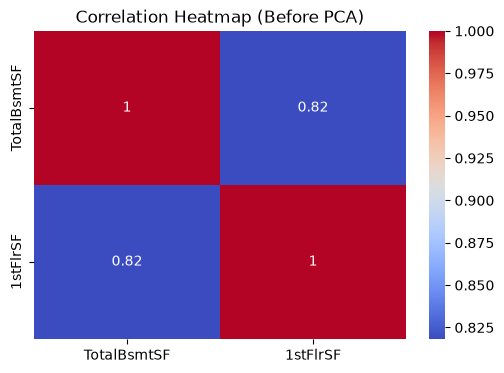

In [228]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['TotalBsmtSF', '1stFlrSF']].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [229]:
from sklearn.decomposition import PCA

X = df_standardized[['TotalBsmtSF', '1stFlrSF']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.90912313 0.09087687]


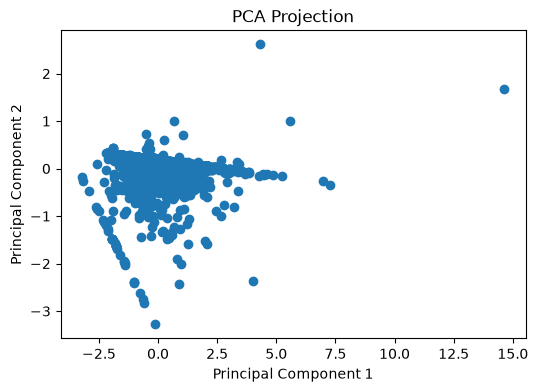

In [230]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [231]:
from sklearn.decomposition import PCA

# 1. Set your correlation threshold
threshold = 0.75
df_standardized_new =df_standardized
# 2. Calculate the absolute correlation matrix for all features
corr_matrix = df_standardized_new.corr().abs()

# 3. Loop through the upper triangle of the matrix to find highly correlated pairs
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        
        # Check if the correlation between two features exceeds the threshold
        if corr_matrix.iloc[i, j] > threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            
            # Ensure both columns are still in the DataFrame (prevents overlapping errors)
            if col1 in df_standardized_new.columns and col2 in df_standardized_new.columns:
                
                print(f"High correlation ({corr_matrix.iloc[i, j]:.2f}) found between {col1} and {col2}.")
                
                # 4. Apply PCA to compress the two features into one
                pca = PCA(n_components=1)
                new_pc_column = f"PCA_{col1}_{col2}"
                df_standardized_new[new_pc_column] = pca.fit_transform(df_standardized_new[[col1, col2]])
                
                # 5. Drop the original redundant columns
                df_standardized_new.drop(columns=[col1, col2], inplace=True)
                print(f"-> Compressed and replaced with {new_pc_column}\n")

df_standardized_new.head()

High correlation (0.79) found between OverallQual and SalePrice.
-> Compressed and replaced with PCA_OverallQual_SalePrice

High correlation (0.82) found between TotalBsmtSF and 1stFlrSF.
-> Compressed and replaced with PCA_TotalBsmtSF_1stFlrSF

High correlation (0.83) found between GrLivArea and TotRmsAbvGrd.
-> Compressed and replaced with PCA_GrLivArea_TotRmsAbvGrd

High correlation (0.88) found between GarageCars and GarageArea.
-> Compressed and replaced with PCA_GarageCars_GarageArea



,Id,MSSubClass,LotFrontage,LotArea,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,PCA_OverallQual_SalePrice,PCA_TotalBsmtSF_1stFlrSF,PCA_GrLivArea_TotRmsAbvGrd,PCA_GarageCars_GarageArea
0,-1.727915,0.072083,-0.220060,-0.206014,-0.520512,1.056331,0.882742,0.510015,0.580026,-0.289513,...,-0.116664,-0.271006,-0.068882,-0.087931,-1.600089,0.138937,0.713259,-0.883495,0.908660,0.471452
1,-1.725545,-0.872973,0.460848,-0.090854,2.175506,0.161798,-0.425058,-0.572835,1.177561,-0.289513,...,-0.116664,-0.271006,-0.068882,-0.087931,-0.488448,-0.613809,-0.039717,0.517896,-0.564240,0.180724
2,-1.723174,0.072083,-0.083879,0.074376,-0.520512,0.990069,0.834305,0.322174,0.096725,-0.289513,...,-0.116664,-0.271006,-0.068882,-0.087931,0.993739,0.138937,0.847083,-0.662586,0.140920,0.669676
3,-1.720803,0.308347,-0.447030,-0.095861,-0.520512,-1.859183,-0.715681,-0.572835,-0.496416,-0.289513,...,-0.116664,-0.271006,-0.068882,-0.087931,-1.600089,-1.366555,0.102133,-0.852042,0.483073,1.727033
4,-1.718432,0.072083,0.642424,0.375794,-0.520512,0.956938,0.737431,1.360826,0.467988,-0.289513,...,-0.116664,-0.271006,-0.068882,-0.087931,2.105380,0.138937,1.595598,0.114047,2.000382,2.367957
